# 258: Do BHF's human matches land on zinc fingers, membrane regions or extracellular parts?

The 2024 Evolgenome talk read BHF's k-mer hits as a zinc-finger DNA-binding region and a
membrane tether, and BHF may also have an extracellular part. BHF is at the membrane in
HEK293 cells (the lab's measurement, independent of kmerseek). This notebook asks whether
kmerseek's matches support any of the three, against a chance level.

**Matches.** BHF and 300 shuffled copies of it were searched against the 19_732 canonical
human proteins (GENCODE v49) at the 152 alphabet-ksize pairs of notebook 241
(`256_bhf_dipeptide_shuffle_null.py --keep-regions`). Each copy keeps BHF's length, amino-acid
counts and counts of adjacent residue pairs, so it has BHF's make-up and no real homolog. For
each query, alphabet-ksize pair and ranking metric, the best region of each of the ten best
human proteins is kept: the matches a reader would look at.

**Classes.** From reviewed UniProt human entries (2025-06-04), matched to the GENCODE
proteins by identical sequence (`bhf_feature_utils.py`):

- zinc finger: UniProt zinc finger regions;
- membrane: transmembrane and intramembrane segments, regions annotated as interacting with
  membranes, and lipid anchors (myristoylation, palmitoylation, prenylation sites) widened by
  5 residues on each side;
- extracellular: extracellular topological domains, and the mature chain of secreted proteins
  with no transmembrane segment;
- disordered: UniProt's MobiDB-lite disordered regions, kept apart, because disorder is
  already predicted from BHF's own sequence.

A match lands on a class when at least half of the human region lies inside it. Zinc finger,
membrane and extracellular are counted outside disordered regions.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import bhf_feature_utils as f
import bhf_shuffle_null_utils as u

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(70)

feats, stats = f.feature_table()
print(f"human proteins with an identical reviewed UniProt entry: {stats['n_matched']:_} of {stats['n_gencode']:_}")
print(feats.group_by("cls").agg(pl.len().alias("intervals"), pl.col("gene").n_unique().alias("proteins")).sort("cls"))
reg = f.load_regions()
print(f"\ntop-10 matches: {reg.height:_} ({reg['query_name'].n_unique()} queries, "
      f"{reg.select('alphabet', 'k').n_unique()} alphabet-ksize pairs where anything was hit)")
lab = f.label_matches(reg, feats)
print(f"in a human protein with a UniProt entry: {lab['annotated'].sum():_}")
bhf = u.bhf_sequence()

human proteins with an identical reviewed UniProt entry: 17_585 of 19_732
shape: (4, 3)
┌───────────────┬───────────┬──────────┐
│ cls           ┆ intervals ┆ proteins │
│ ---           ┆ ---       ┆ ---      │
│ str           ┆ u32       ┆ u32      │
╞═══════════════╪═══════════╪══════════╡
│ disordered    ┆ 22252     ┆ 9724     │
│ extracellular ┆ 8442      ┆ 4131     │
│ membrane      ┆ 20472     ┆ 5280     │
│ zinc finger   ┆ 8066      ┆ 1579     │
└───────────────┴───────────┴──────────┘



top-10 matches: 2_503_298 (301 queries, 135 alphabet-ksize pairs where anything was hit)


in a human protein with a UniProt entry: 2_079_819


## 1. The share of matches on each class, BHF against its copies

For each query: the % of its top-10 matches (over all alphabet-ksize pairs and metrics) whose
human region lies on each class. p is the share of copies at least as high as BHF,
(1 + copies at least as high) / 301.

shape: (7, 7)
┌───────────────────────────┬─────────┬───────────────────┬─────────────┬──────────────┬──────────┬────────┐
│ measure                   ┆ bhf_pct ┆ copies_median_pct ┆ copies_p2_5 ┆ copies_p97_5 ┆ n_copies ┆ p      │
│ ---                       ┆ ---     ┆ ---               ┆ ---         ┆ ---          ┆ ---      ┆ ---    │
│ str                       ┆ f64     ┆ f64               ┆ f64         ┆ f64          ┆ u32      ┆ f64    │
╞═══════════════════════════╪═════════╪═══════════════════╪═════════════╪══════════════╪══════════╪════════╡
│ pct_disordered            ┆ 41.21   ┆ 28.36             ┆ 22.41       ┆ 39.04        ┆ 300      ┆ 0.01   │
│ pct_extracellular         ┆ 12.66   ┆ 12.94             ┆ 9.71        ┆ 16.64        ┆ 300      ┆ 0.5714 │
│ pct_extracellular_ordered ┆ 8.61    ┆ 10.24             ┆ 7.69        ┆ 13.65        ┆ 300      ┆ 0.8804 │
│ pct_membrane              ┆ 3.01    ┆ 1.58              ┆ 0.75        ┆ 4.04         ┆ 300      ┆ 0.0897 │
│ pct

shape: (11, 5)
┌─────────────────────────┬─────────────────────────┬──────────────────────┬───────────────────────────┬────────────────┐
│ metric                  ┆ pct_zinc_finger_ordered ┆ pct_membrane_ordered ┆ pct_extracellular_ordered ┆ pct_disordered │
│ ---                     ┆ ---                     ┆ ---                  ┆ ---                       ┆ ---            │
│ str                     ┆ f64                     ┆ f64                  ┆ f64                       ┆ f64            │
╞═════════════════════════╪═════════════════════════╪══════════════════════╪═══════════════════════════╪════════════════╡
│ E-value                 ┆ 0.6312                  ┆ 0.3056               ┆ 0.5648                    ┆ 0.5914         │
│ Poisson p-value         ┆ 0.5615                  ┆ 0.113                ┆ 0.6113                    ┆ 0.0199         │
│ Poisson score           ┆ 0.5615                  ┆ 0.113                ┆ 0.6113                    ┆ 0.0199         │
│ bit sco

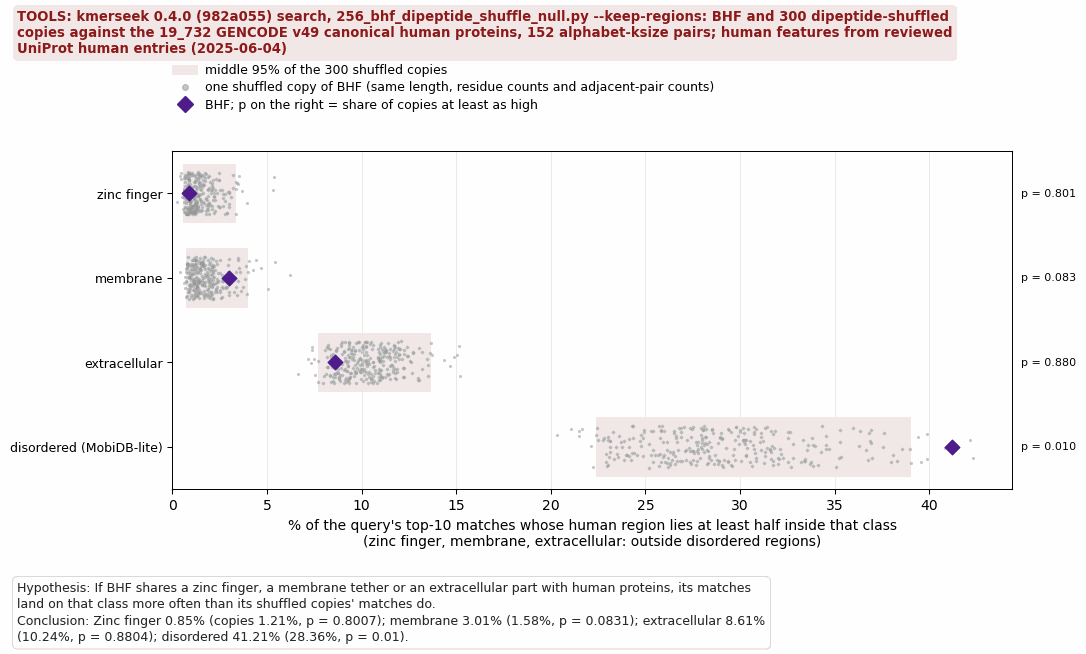

In [2]:
shares = f.class_shares(lab)
test = f.class_test(shares)
print(test)
t = {r["measure"]: r for r in test.iter_rows(named=True)}
f.fig_class_shares(
    shares, test, u.FIG / "258_classes_bhf_vs_copies.png",
    hypothesis="If BHF shares a zinc finger, a membrane tether or an extracellular part with human proteins, its matches land on that class more often than its shuffled copies' matches do.",
    conclusion=(f"Zinc finger {t['pct_zinc_finger_ordered']['bhf_pct']}% (copies {t['pct_zinc_finger_ordered']['copies_median_pct']}%, p = {t['pct_zinc_finger_ordered']['p']}); "
                f"membrane {t['pct_membrane_ordered']['bhf_pct']}% ({t['pct_membrane_ordered']['copies_median_pct']}%, p = {t['pct_membrane_ordered']['p']}); "
                f"extracellular {t['pct_extracellular_ordered']['bhf_pct']}% ({t['pct_extracellular_ordered']['copies_median_pct']}%, p = {t['pct_extracellular_ordered']['p']}); "
                f"disordered {t['pct_disordered']['bhf_pct']}% ({t['pct_disordered']['copies_median_pct']}%, p = {t['pct_disordered']['p']})."),
)
print("\nper ranking metric, p for each class:")
bym = f.class_test(f.class_shares(lab, ["metric"]), ["metric"])
print(bym.filter(pl.col("measure").is_in(list(f.MEASURE_LABEL))).pivot(on="measure", index="metric", values="p")
         .select(["metric"] + list(f.MEASURE_LABEL)).sort("metric"))

Zinc finger and extracellular: BHF is not above its copies. 0.85% of BHF's matches land on
a zinc finger against a median of 1.21% for the copies (p = 0.80), and 8.61% on an
extracellular part against 10.24% (p = 0.88). Membrane: 3.01% against 1.58%, above most
copies but reached by about 1 copy in 12 (p = 0.083). Disordered: 41.2% against 28.4%
(p = 0.010), the one clear difference, and it comes from BHF's lysine-rich stretch (notebook
256).

No single ranking metric puts BHF above its copies for any of the three classes at p ≤ 0.05;
the lowest is 0.066 (membrane, protein Poisson p-value). For disordered regions every counting
metric does (p = 0.010 to 0.030); the E-value does not (p = 0.59).

## 2. Membrane, alphabet by alphabet

The same comparison for the membrane class, one alphabet at a time (all its k-mer sizes and
metrics together). With 19 alphabets, about one is expected at p ≤ 0.05 by chance.

shape: (19, 8)
┌──────────────────────────┬──────────────────────┬─────────┬───────────────────┬─────────────┬──────────────┬──────────┬────────┐
│ alphabet                 ┆ measure              ┆ bhf_pct ┆ copies_median_pct ┆ copies_p2_5 ┆ copies_p97_5 ┆ n_copies ┆ p      │
│ ---                      ┆ ---                  ┆ ---     ┆ ---               ┆ ---         ┆ ---          ┆ ---      ┆ ---    │
│ str                      ┆ str                  ┆ f64     ┆ f64               ┆ f64         ┆ f64          ┆ u32      ┆ f64    │
╞══════════════════════════╪══════════════════════╪═════════╪═══════════════════╪═════════════╪══════════════╪══════════╪════════╡
│ polarity4                ┆ pct_membrane_ordered ┆ 22.5    ┆ 2.96              ┆ 0.0         ┆ 18.13        ┆ 300      ┆ 0.0133 │
│ gbmr7                    ┆ pct_membrane_ordered ┆ 22.17   ┆ 5.27              ┆ 0.0         ┆ 22.95        ┆ 300      ┆ 0.0399 │
│ dayhoff6                 ┆ pct_membrane_ordered ┆ 0.91    ┆ 0.29  

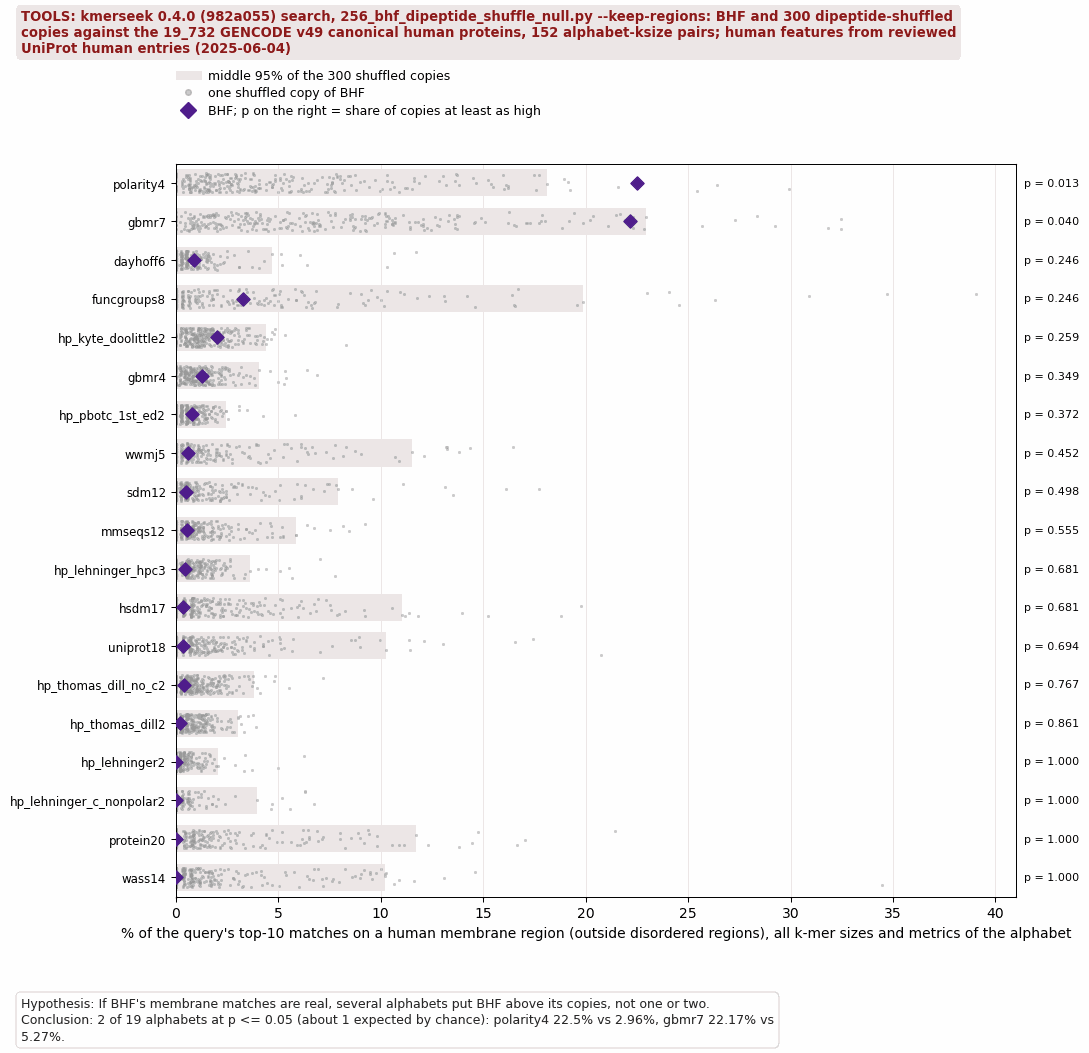

In [3]:
sh_a = f.class_shares(lab, ["alphabet"])
te_a = f.class_test(sh_a, ["alphabet"])
mem = te_a.filter(pl.col("measure") == "pct_membrane_ordered").sort("p")
print(mem)
n_low = (mem["p"] <= 0.05).sum()
f.fig_membrane_by_alphabet(
    sh_a, te_a, u.FIG / "258_membrane_by_alphabet.png",
    hypothesis="If BHF's membrane matches are real, several alphabets put BHF above its copies, not one or two.",
    conclusion=f"{n_low} of {mem.height} alphabets at p <= 0.05 (about 1 expected by chance): "
               + ", ".join(f"{r['alphabet']} {r['bhf_pct']}% vs {r['copies_median_pct']}%" for r in mem.filter(pl.col('p') <= 0.05).iter_rows(named=True)) + ".",
)

Two of the 19 alphabets put BHF above its copies on membrane regions: polarity4 (22.5% of
BHF's matches against a median of 2.96% for the copies, p = 0.013) and gbmr7 (22.2% against
5.27%, p = 0.040). About one is expected at p ≤ 0.05 by chance. The next alphabet is at
p = 0.25. The two are examined in section 3.

## 3. Where on BHF the matches come from, and what they match

BHF drawn as a line; each panel counts, for every BHF residue, the top-10 matches on that
class (outside disordered regions) whose BHF stretch covers the residue. The tables list each
match once per BHF stretch and human protein, with the residues on both sides.

shape: (3, 3)
┌───────────────┬─────────────────────────────┬────────────┐
│ cls           ┆ most matches on one residue ┆ at residue │
│ ---           ┆ ---                         ┆ ---        │
│ str           ┆ i64                         ┆ i64        │
╞═══════════════╪═════════════════════════════╪════════════╡
│ extracellular ┆ 162                         ┆ 127        │
│ membrane      ┆ 122                         ┆ 223        │
│ zinc finger   ┆ 32                          ┆ 198        │
└───────────────┴─────────────────────────────┴────────────┘

zinc finger: 23 distinct BHF-human matches; the most frequent:
shape: (10, 7)
┌────────┬──────────┬────────┬─────────┬──────────────────────────────┬───────────────────────────────────────────────────┬───────────────────────────────────────────────────┐
│ gene   ┆ bhf_from ┆ bhf_to ┆ n_cells ┆ alphabets                    ┆ bhf_residues                                      ┆ human_residues                                    │
│ --- 

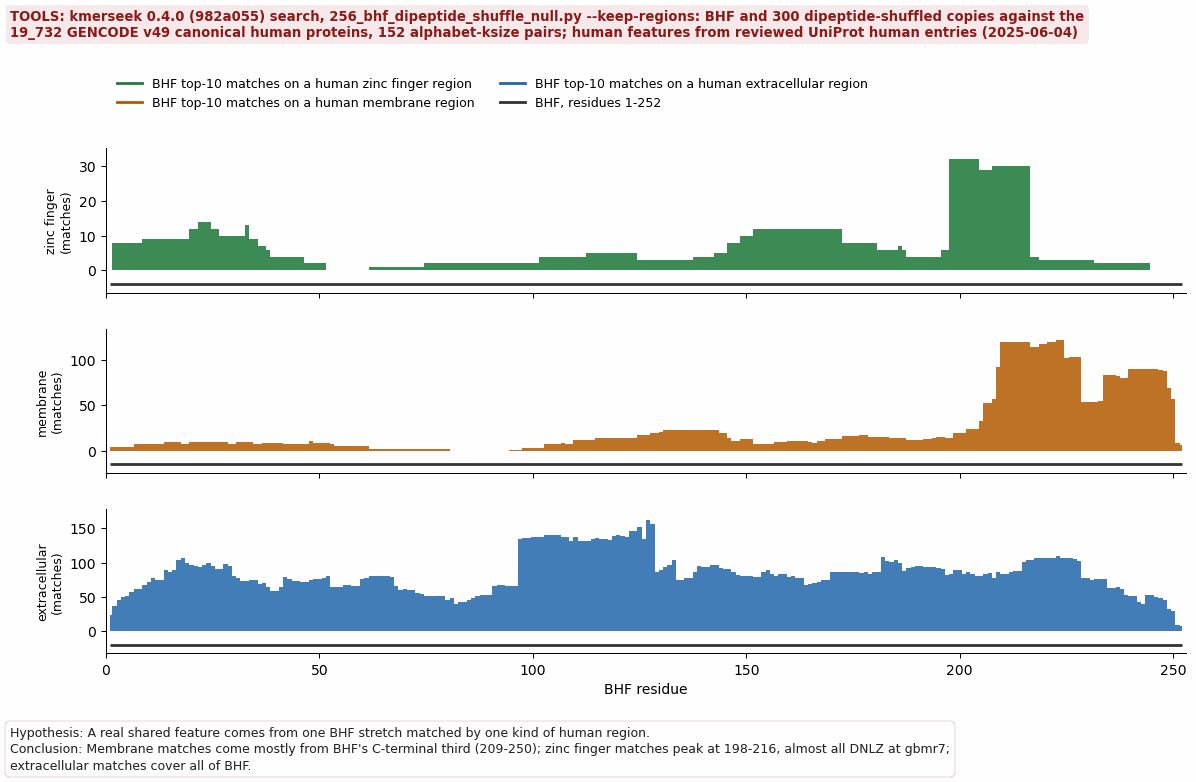

In [4]:
cov = f.fig_where_on_bhf(
    lab, bhf, u.FIG / "258_where_on_bhf.png",
    hypothesis="A real shared feature comes from one BHF stretch matched by one kind of human region.",
    conclusion="Membrane matches come mostly from BHF's C-terminal third (209-250); zinc finger matches peak at 198-216, almost all DNLZ at gbmr7; extracellular matches cover all of BHF.",
)
print(cov.group_by("cls").agg(pl.col("n_matches").max().alias("most matches on one residue"),
                              pl.col("residue").filter(pl.col("n_matches") == pl.col("n_matches").max()).min().alias("at residue")))
for c in f.MAIN:
    t_ = f.with_residues(f.bhf_class_matches(lab, c), bhf)
    print(f"\n{c}: {t_.height} distinct BHF-human matches; the most frequent:")
    print(t_.select("gene", pl.col("region_start").alias("bhf_from"), pl.col("region_end").alias("bhf_to"),
                    "n_cells", "alphabets", "bhf_residues", "human_residues").head(10))

### What the membrane matches look like in the alphabet that found them

Each residue written as its class number in that alphabet. A match counts every position
where both sides fall in the same class, so the two strings below are what kmerseek compared.

In [5]:
mt = f.with_residues(f.bhf_class_matches(lab, "membrane"), bhf)
for a in ["gbmr7", "polarity4"]:
    print(f"{a} classes: " + "  ".join(f"{i}={c}" for i, c in enumerate(f.CLUSTERS[a])))
    x = f.class_agreement(mt.filter(pl.col("alphabets").list.contains(a)), a)
    print(x.select("gene", pl.col("region_start").alias("bhf_from"), "n_cells", "bhf_residues", "human_residues",
                   "bhf_encoded", "human_encoded", "same_class", "identical", "length").head(6))
    print()

gbmr7 classes: 0=DN  1=AEFIKLMQRVWY  2=CH  3=T  4=S  5=G  6=P
shape: (6, 10)
┌─────────┬──────────┬─────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬────────────┬───────────┬────────┐
│ gene    ┆ bhf_from ┆ n_cells ┆ bhf_residues         ┆ human_residues       ┆ bhf_encoded          ┆ human_encoded        ┆ same_class ┆ identical ┆ length │
│ ---     ┆ ---      ┆ ---     ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---        ┆ ---       ┆ ---    │
│ str     ┆ i64      ┆ u32     ┆ str                  ┆ str                  ┆ str                  ┆ str                  ┆ i64        ┆ i64       ┆ u32    │
╞═════════╪══════════╪═════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪════════════╪═══════════╪════════╡
│ TMEM80  ┆ 208      ┆ 35      ┆ KKARKRIRTVMKATWQSLQA ┆ YYALYFLATLLMITYKSQVF ┆ 11111111311113114111 ┆ 11111111311113114111 ┆ 20 

**Membrane.** The matches come from BHF's C-terminal third, most of them covering residue 223
(122 matches). Two alphabets give two different stories:

- gbmr7 pairs BHF's basic stretch KKARKRIRTVMKATWQSLQA (residues 209-228) with transmembrane
  helices such as TMEM80's YYALYFLATLLMITYKSQVF. In gbmr7 the two are in the same class at 20
  of 20 positions, with 4 identical residues. gbmr7 puts the charged K, R, E and Q in one class
  with the hydrophobic L, I, V and F, so a basic stretch and a membrane helix look alike to it.
  These matches are not evidence for a membrane feature.
- polarity4 pairs BHF 234-250, TAFLNPQGAVSAALVQN, with transmembrane helices of SLC36A4
  (SFLANVSMAVSLVIIYQ), SLC36A1 and PARL. polarity4 separates nonpolar, polar, acidic and basic
  residues, and the two sides have the same order of nonpolar and polar residues at 17 of 17
  positions, with 4 identical residues. This is the one membrane match that reflects a pattern
  a biologist would recognise.

**Zinc finger.** 23 distinct matches, most found at one alphabet only. The most frequent,
DNLZ at gbmr7 (26 cells), pairs BHF 198-216 with a stretch of DNLZ's zinc finger that has no
cysteine. The closest in residues is MIB2: CKKHGI (BHF 33-38) against CKKHGL, 5 of 6
identical, too short to mean anything on its own.

**Extracellular.** Spread along BHF; the most matches cover residue 127 (162). With the
disordered mucin and collagen stretches removed, BHF is below its copies (section 1).

## 4. BHF's own sequence: a membrane-spanning or amphipathic helix?

Independent of kmerseek. A membrane-spanning helix shows as a 19-residue window with a
Kyte-Doolittle average above 1.6. A helix that lies on the membrane surface (an amphipathic
helix: one face hydrophobic, one face charged) shows as a high hydrophobic moment on an
18-residue helix. The moment is compared with the highest window of 1_000 copies of BHF with
its residues shuffled.

highest Kyte-Doolittle window: 0.45 at residues 230-248 (ARSQTAFLNPQGAVSAALV); cutoff 1.6
highest hydrophobic moment: 0.549 at residues 215-232 (IRTVMKATWQSLQAGARS); shuffled copies' highest: median 0.515, 95th percentile 0.638; p = 0.317


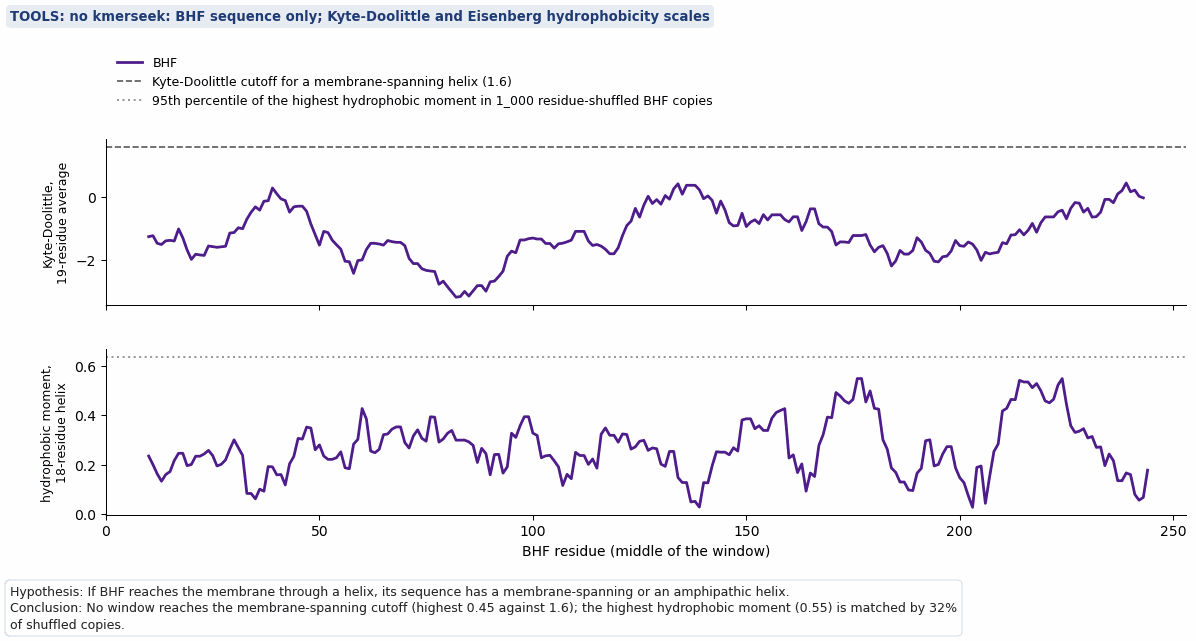

In [6]:
prof = f.helix_profiles(bhf)
null = f.helix_null(bhf)
kd_max = prof["kyte_doolittle"].max()
kd_at = prof.filter(pl.col("kyte_doolittle") == kd_max)["start"][0]
mh_max = prof["hydrophobic_moment"].max()
mh_at = prof.filter(pl.col("hydrophobic_moment") == mh_max)["start"][0]
p_mh = (1 + (null["max_hydrophobic_moment"] >= mh_max).sum()) / (1 + null.height)
print(f"highest Kyte-Doolittle window: {kd_max:.2f} at residues {kd_at}-{kd_at + f.TM_WINDOW - 1} "
      f"({bhf[kd_at - 1:kd_at - 1 + f.TM_WINDOW]}); cutoff {f.TM_CUTOFF}")
print(f"highest hydrophobic moment: {mh_max:.3f} at residues {mh_at}-{mh_at + f.HELIX_WINDOW - 1} "
      f"({bhf[mh_at - 1:mh_at - 1 + f.HELIX_WINDOW]}); shuffled copies' highest: median "
      f"{null['max_hydrophobic_moment'].median():.3f}, 95th percentile {null['max_hydrophobic_moment'].quantile(0.95):.3f}; p = {p_mh:.3f}")
f.fig_helix_profiles(
    bhf, prof, null, u.FIG / "258_bhf_helix_profiles.png",
    hypothesis="If BHF reaches the membrane through a helix, its sequence has a membrane-spanning or an amphipathic helix.",
    conclusion=f"No window reaches the membrane-spanning cutoff (highest {kd_max:.2f} against 1.6); the highest hydrophobic moment ({mh_max:.2f}) is matched by {p_mh:.0%} of shuffled copies.",
)

No 19-residue window of BHF reaches the Kyte-Doolittle cutoff for a membrane-spanning helix:
the highest is 0.45 at residues 230-248 (ARSQTAFLNPQGAVSAALV), against 1.6. The strongest
amphipathic helix, residues 215-232 (IRTVMKATWQSLQAGARS, hydrophobic moment 0.549), is matched
or beaten by 32% of copies with BHF's residues shuffled (p = 0.317).

So BHF 230-250 has the nonpolar-polar order of a membrane helix (section 3) but not its
hydrophobicity. BHF also has no glycine at position 2 (it starts MVHD), so it has no
N-terminal myristoylation site. How BHF reaches the membrane is not shown by its sequence
alone. Residues 209-220 (KKARKRIRTVMK: 7 of 12 are K or R) and the 230-250 stretch are the two
candidates a truncation or mutation experiment could test.

## Summary

- **Zinc finger:** no support. BHF's matches land on human zinc fingers less often than its
  shuffled copies' matches (0.85% against 1.21%, p = 0.80).
- **Extracellular:** no support once disordered regions are set aside (8.61% against
  10.24%, p = 0.88). Most extracellular matches are mucin and collagen stretches that
  MobiDB-lite calls disordered.
- **Membrane:** weak support from one alphabet. Pooled, BHF is at 3.01% against 1.58%
  (p = 0.083). Of the two alphabets that single it out, gbmr7's matches are an artefact of an
  alphabet that cannot tell charged from hydrophobic residues. polarity4's are a real
  pattern: BHF 234-250 has the order of nonpolar and polar residues of human transmembrane
  helices (SLC36A4, SLC36A1, PARL), but BHF's stretch is not hydrophobic enough to span a
  membrane (Kyte-Doolittle 0.45 against the 1.6 cutoff).
- **Disordered:** the one clear difference from the copies (41.2% against 28.4%, p = 0.010),
  as expected from BHF's lysine-rich stretch and its MobiDB-lite prediction.

The E-value, the one metric with its own chance scale, supports none of the four (p = 0.31 to
0.63). Repeating the 256 search for this notebook changed some E-values and bit scores in the
twelfth decimal place (a kmerseek rounding difference between runs); it reordered 76 of
293_315 top proteins and no result here.

What would test the membrane lead: BHF with residues 230-252 removed, or with 209-220 changed
to neutral residues, in the lab's HEK293 membrane assay.